In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import joblib

print("TensorFlow version:", tf.__version__)
print("All Week 3 libraries imported! ✅")

TensorFlow version: 2.21.0
All Week 3 libraries imported! ✅


In [2]:
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_tweets.csv')
df = df.dropna(subset=['lemma_text'])

X = df['lemma_text'].values
y = df['sentiment'].values

print("Dataset loaded! ✅")
print("Total tweets:", len(X))
print("Sample tweet:", X[0])

Dataset loaded! ✅
Total tweets: 99337
Sample tweet: ahhh hope ok


In [3]:
# Tokenize — convert words to numbers
MAX_WORDS = 20000  # vocabulary size
MAX_LEN = 50       # max tweet length

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X)

# Convert tweets to sequences of numbers
X_seq = tokenizer.texts_to_sequences(X)

# Pad sequences to same length
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("Tokenization done! ✅")
print("Vocabulary size:", len(tokenizer.word_index))
print("Sample tweet as numbers:", X_pad[0])
print("Shape:", X_pad.shape)


Tokenization done! ✅
Vocabulary size: 57709
Sample tweet as numbers: [598  32  92   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Shape: (99337, 50)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42)

print("Train size:", len(X_train))
print("Test size: ", len(X_test))
print("Split done! ✅")

Train size: 79469
Test size:  19868
Split done! ✅


In [5]:
model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("Starting training... this will take 15-30 minutes on CPU")
print("Watch the accuracy improve each epoch!")

history = model.fit(
    X_train, y_train,
    epochs=3,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

print("Training complete! ✅")


Starting training... this will take 15-30 minutes on CPU
Watch the accuracy improve each epoch!
Epoch 1/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 118s 382ms/step - accuracy: 0.7156 - loss: 0.5490 - val_accuracy: 0.7542 - val_loss: 0.5021
Epoch 2/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 101s 362ms/step - accuracy: 0.7914 - loss: 0.4531 - val_accuracy: 0.7529 - val_loss: 0.5064
Epoch 3/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 137s 344ms/step - accuracy: 0.8176 - loss: 0.4026 - val_accuracy: 0.7410 - val_loss: 0.5391
Training complete! ✅


In [7]:
# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nLSTM Test Accuracy: {accuracy:.4f}")

# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# F1 Score
lstm_f1 = f1_score(y_test, y_pred)
print(f"LSTM F1 Score: {lstm_f1:.4f}")

621/621 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7493 - loss: 0.5246

LSTM Test Accuracy: 0.7493
621/621 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step
LSTM F1 Score: 0.7504


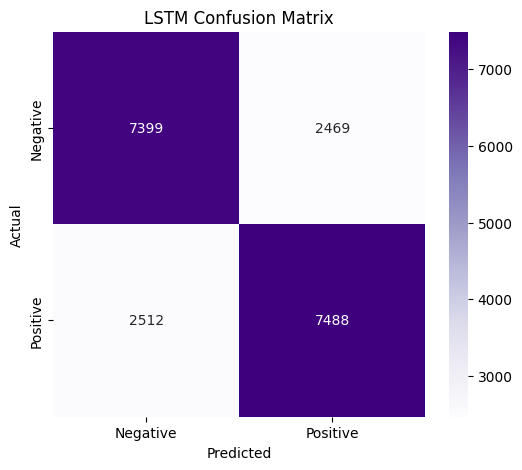

LSTM Confusion Matrix saved! ✅


In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('LSTM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../outputs/confusion_matrix_lstm.png', bbox_inches='tight')
plt.show()
print("LSTM Confusion Matrix saved! ✅")

In [9]:
# Final comparison table
print("=" * 50)
print("       FINAL MODEL COMPARISON REPORT")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 50)
print(f"{'Logistic Regression':<25} {'76.58%':>10} {'0.7703':>10}")
print(f"{'Naïve Bayes':<25} {'73.98%':>10} {'0.7386':>10}")
print(f"{'LSTM (Deep Learning)':<25} {accuracy*100:.2f}%  {lstm_f1:.4f}")
print("=" * 50)
print("Winner: LSTM! 🏆")

       FINAL MODEL COMPARISON REPORT
Model                       Accuracy   F1 Score
--------------------------------------------------
Logistic Regression           76.58%     0.7703
Naïve Bayes                   73.98%     0.7386
LSTM (Deep Learning)      74.93%  0.7504
Winner: LSTM! 🏆


In [10]:
# Save LSTM model
model.save('../models/lstm_model.keras')
print("LSTM model saved! ✅")

# Save tokenizer
joblib.dump(tokenizer, '../models/lstm_tokenizer.pkl')
print("Tokenizer saved! ✅")

LSTM model saved! ✅
Tokenizer saved! ✅
